In [5]:
import pandas as pd
import numpy as np
import pickle
import shap
import dice_ml
from dice_ml import Dice
import matplotlib.pyplot as plt


train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train_data.csv')
test  = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/test_data.csv')

X_train = train.drop('target', axis=1)
y_train = train['target']
X_test  = test.drop('target', axis=1)
y_test  = test['target']

X_enrolled = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/enrolled_inference.csv')


with open('/content/drive/MyDrive/Colab Notebooks/xgb_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

with open('/content/drive/MyDrive/Colab Notebooks/stacking_model.pkl', 'rb') as f:
    stacking_model = pickle.load(f)

with open('/content/drive/MyDrive/Colab Notebooks/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

print("Everything loaded successfully!")
print(f"X_test shape: {X_test.shape}")

Everything loaded successfully!
X_test shape: (726, 232)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


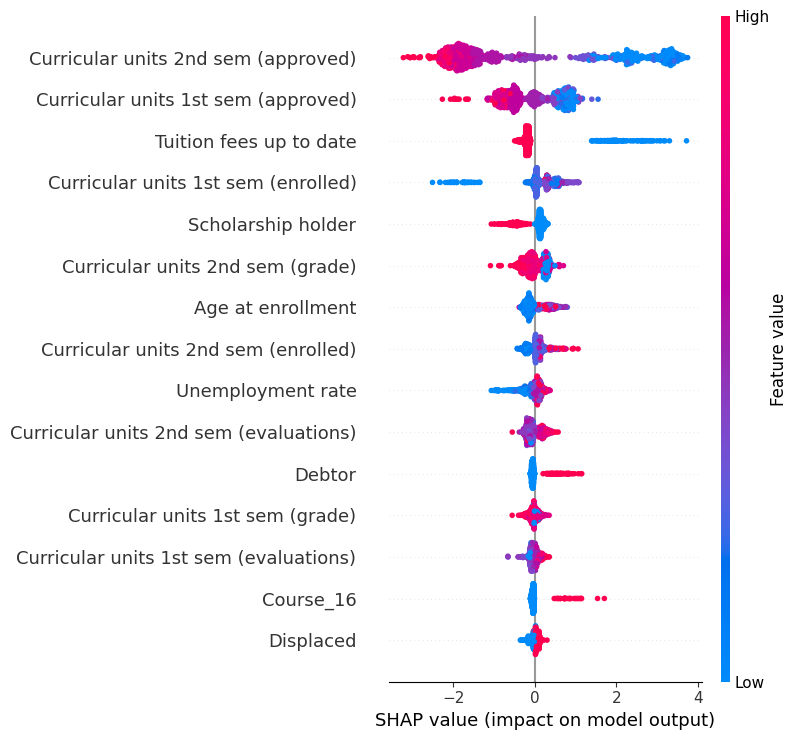

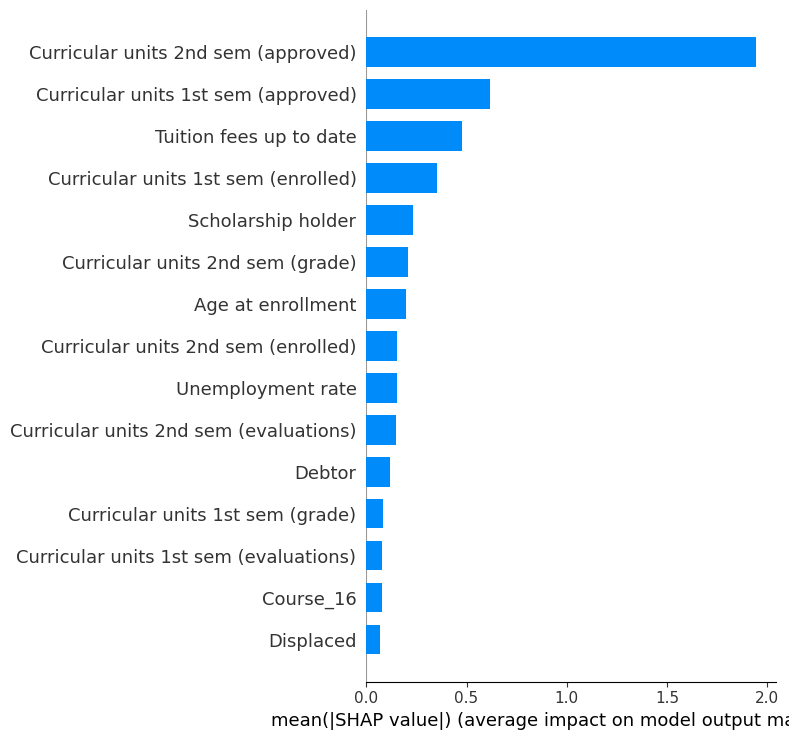

In [8]:
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_xgb, X_test, plot_type="dot", max_display=15)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar", max_display=15)

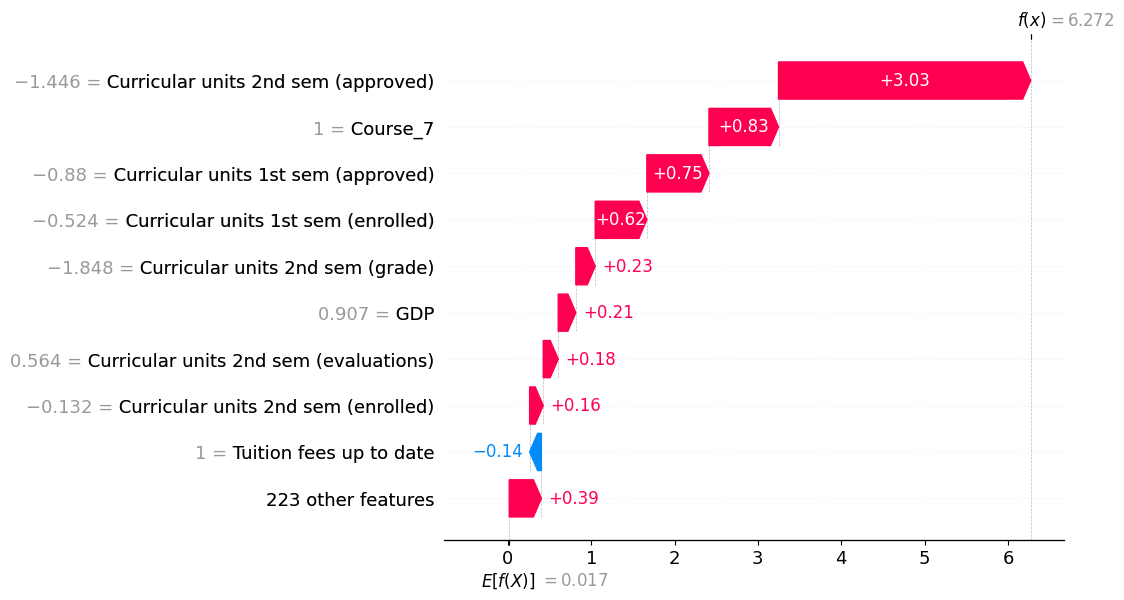

<Figure size 1000x500 with 0 Axes>

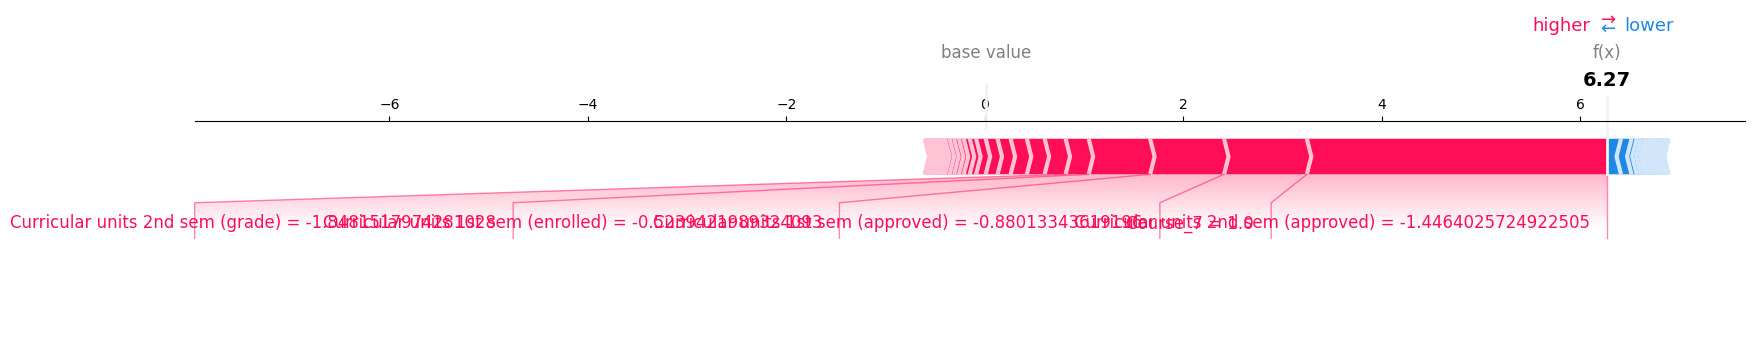

<Figure size 1000x600 with 0 Axes>

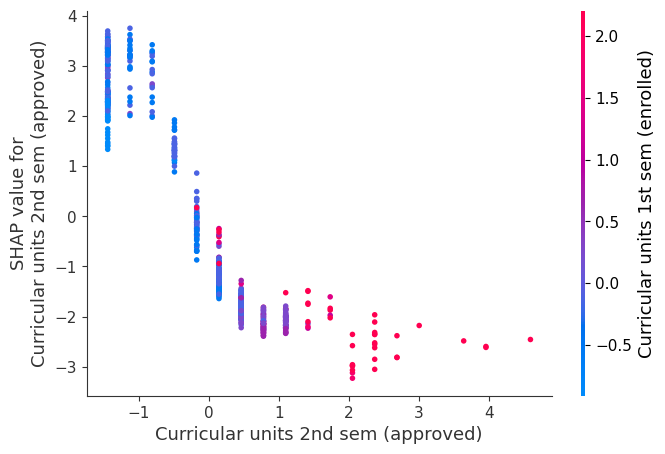

In [10]:
student_index = 32

plt.figure(figsize=(10, 7))
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_xgb[student_index],
        base_values=explainer_xgb.expected_value,
        data=X_test.iloc[student_index],
        feature_names=X_test.columns.tolist()
    )
)

plt.figure(figsize=(10, 5))
shap.force_plot(
    explainer_xgb.expected_value,
    shap_values_xgb[student_index],
    X_test.iloc[student_index],
    matplotlib=True
)

top_feature = 'Curricular units 2nd sem (approved)'
plt.figure(figsize=(10, 6))
shap.dependence_plot(top_feature, shap_values_xgb, X_test)

In [15]:
train_with_target = X_train.copy()
train_with_target['target'] = y_train.values

# Convert problematic columns to float type for consistency with XGBoost
columns_to_convert_to_numeric = ['Debtor', 'Tuition fees up to date']
for col in columns_to_convert_to_numeric:
    if col in train_with_target.columns:
        train_with_target[col] = train_with_target[col].astype(float)

continuous_cols = [
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP',
]

# Add 'Debtor' and 'Tuition fees up to date' to continuous_cols for dice_ml.Data
continuous_cols.extend(columns_to_convert_to_numeric)

d = dice_ml.Data(
    dataframe=train_with_target,
    continuous_features=[c for c in continuous_cols if c in X_train.columns],
    outcome_name='target'
)
m = dice_ml.Model(model=stacking_model, backend='sklearn')
exp = Dice(d, m, method='random')
actionable_features = [
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Tuition fees up to date',
    'Debtor',
    'Curricular units 1st sem (approved)',
]
student_to_explain = X_test.iloc[[student_index]].copy() # Use .copy() to avoid SettingWithCopyWarning
# Convert problematic columns to float type for the student_to_explain DataFrame
for col in columns_to_convert_to_numeric:
    if col in student_to_explain.columns:
        student_to_explain[col] = student_to_explain[col].astype(float)

counterfactuals = exp.generate_counterfactuals(
    student_to_explain,
    total_CFs=3,
    desired_class=0,
    features_to_vary=actionable_features
)
counterfactuals.visualize_as_dataframe(show_only_changes=True)
cf_df = counterfactuals.cf_examples_list[0].final_cfs_df
original_row = student_to_explain.copy()
original_row['target'] = 'DROPOUT (Current Prediction)'

print("=" * 60)
print(f"Student #{student_index} — Current Prediction: DROPOUT")
print("=" * 60)
print("\nWhat would need to change to predict GRADUATE instead:\n")
counterfactuals.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:01<00:00,  1.03s/it]

Query instance (original outcome : 1)


,Daytime/evening attendance,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),...,Father's occupation_38,Father's occupation_39,Father's occupation_40,Father's occupation_41,Father's occupation_42,Father's occupation_43,Father's occupation_44,Father's occupation_45,Father's occupation_46,target
0,1,1,0,0.0,1.0,1,0,-0.570564,0,-0.304182,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1



Diverse Counterfactual set (new outcome: 0)


,Daytime/evening attendance,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),...,Father's occupation_38,Father's occupation_39,Father's occupation_40,Father's occupation_41,Father's occupation_42,Father's occupation_43,Father's occupation_44,Father's occupation_45,Father's occupation_46,target
0,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
1,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
2,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0


Student #32 — Current Prediction: DROPOUT

What would need to change to predict GRADUATE instead:

Query instance (original outcome : 1)


,Daytime/evening attendance,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),...,Father's occupation_38,Father's occupation_39,Father's occupation_40,Father's occupation_41,Father's occupation_42,Father's occupation_43,Father's occupation_44,Father's occupation_45,Father's occupation_46,target
0,1,1,0,0.0,1.0,1,0,-0.570564,0,-0.304182,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1



Diverse Counterfactual set (new outcome: 0)


,Daytime/evening attendance,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),...,Father's occupation_38,Father's occupation_39,Father's occupation_40,Father's occupation_41,Father's occupation_42,Father's occupation_43,Father's occupation_44,Father's occupation_45,Father's occupation_46,target
0,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
1,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
2,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,0.0
